In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import pyreadr
from jax.experimental.ode import odeint
from jax.random import PRNGKey
from numpyro.infer import init_to_sample, MCMC, NUTS, Predictive
numpyro.set_host_device_count(4)

In [2]:
seed = 739485
key = jax.random.key(seed)

In [3]:
def f(t, z, R, K):
    dz_dt = R*z*(1 - z/K)

    return dz_dt

In [4]:
df = pyreadr.read_r('data/data.Rda')[None]
df.head().style.hide(axis='index')

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


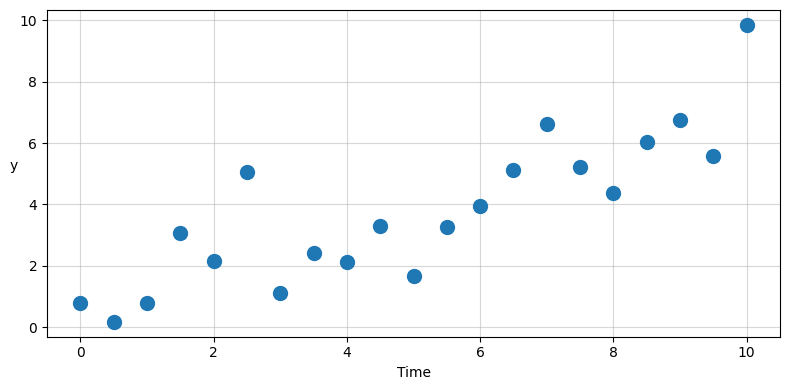

In [5]:
t = df['time'].to_numpy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)
ax.scatter(t, df['y'], s=100, zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel(ylabel='y', rotation=0.)
fig.tight_layout()

In [6]:
def model(t, y=None):
    y0 = numpyro.sample('y0', dist.Normal(0., 1.))
    S = numpyro.sample('S', dist.Normal(jnp.zeros(1), jnp.ones(1)))
    R = numpyro.sample('R', dist.Normal(jnp.zeros(1), jnp.ones(1)))
    K = numpyro.sample('K', dist.Normal(10.*jnp.ones(1), jnp.ones(1)))
    z = odeint(f, y0, t, R, K)

    if y is not None:
        numpyro.sample('y', dist.Normal(z, S), obs=y)
    else:
        numpyro.sample('y', dist.Normal(z, S))

In [7]:
sampler = NUTS(model, init_strategy=init_to_sample())
fit = MCMC(sampler, num_warmup=1000, num_samples=1000, num_chains=4)
fit.run(PRNGKey(seed), t=df['time'].to_numpy(), y=df['y'].to_numpy())

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

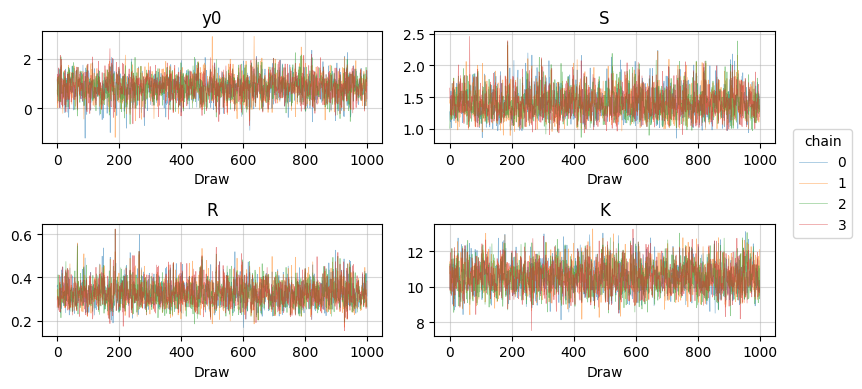

In [8]:
params = list((draws := fit.get_samples()).keys())[::-1]
fig, axes = plt.subplots(round(len(params)/2), 2, figsize=(8, 4))

for ax, param in zip(axes.flatten(), params):
    ax.grid(alpha=.5)
    param_draws = draws[param].reshape(fit.num_samples, fit.num_chains)
    param_lines = ax.plot(param_draws, alpha=.5, linewidth=.5)
    ax.set(title=param, xlabel='Draw')

fig.legend(param_lines, jnp.arange(fit.num_chains), title='chain', bbox_to_anchor=(1.08, .68))
fig.tight_layout()

In [9]:
fit.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      K[0]     10.58      0.83     10.57      9.21     11.95   2237.62      1.00
      R[0]      0.33      0.06      0.32      0.23      0.42   1616.68      1.00
      S[0]      1.41      0.23      1.39      1.03      1.76   2165.31      1.00
        y0      0.86      0.48      0.88      0.10      1.67   1797.05      1.00

Number of divergences: 0


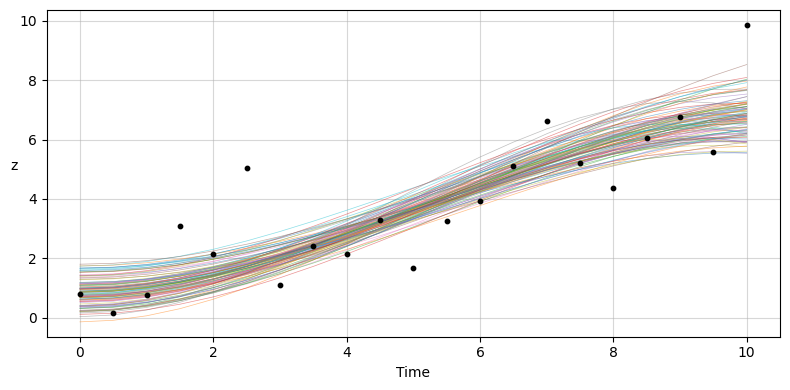

In [11]:
sample_idx = jax.random.choice(key, fit.num_chains*fit.num_samples, (100,))
param_draws = draws['y0'][sample_idx], draws['R'][sample_idx], draws['K'][sample_idx]
z = jnp.stack([odeint(f, y0, t, R, K) for y0, R, K in zip(*param_draws)]).T
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)
ax.plot(t, z, alpha=.5, linewidth=.5)
ax.scatter(t, df['y'], s=10, c='black', zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel('z', rotation=0.)
fig.tight_layout()

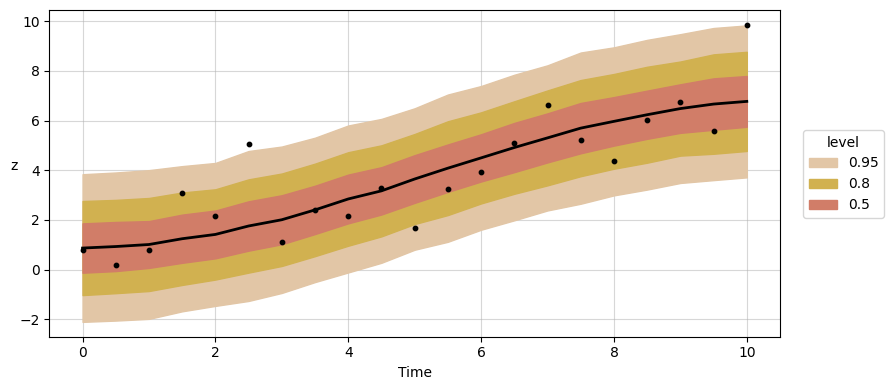

In [13]:
predictive = Predictive(model, draws)
y = (y_draws := predictive(key, df['time'].to_numpy())['y'].T).mean(-1)
d = jnp.sort(jnp.sqrt(jnp.square((y_draws - y[:, None]))), -1)
levels, colors, fills = (.95, .8, .5), ('#e2c6a6', '#d1b150', '#d17d68'), []
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)

for level, color in zip(levels, colors):
    h = d[:, round(level*d.shape[1])]
    fills.append(ax.fill_between(df['time'], y - h, y + h, color=color, zorder=2))

ax.plot(t, y, linewidth=2., color='black')
ax.scatter(t, df['y'], s=10, c='black', zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel('z', rotation=0.)
fig.legend(fills, levels, title='level', bbox_to_anchor=(1.12, .68))
fig.tight_layout()

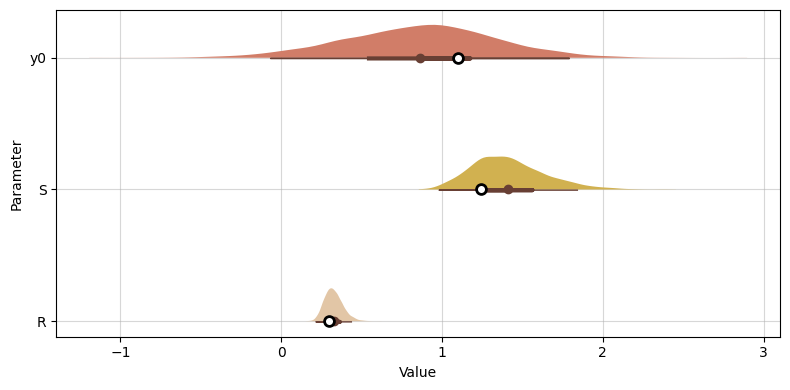

In [30]:
true_params = pyreadr.read_r('data/params.Rda')['params']
param_keys = [param for param in params if param in true_params][::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)

for (idx, param), color in zip(enumerate(param_keys), colors):
    vp = ax.violinplot(draws[param], [idx], orientation='horizontal', showextrema=False, side='high')
    vp['bodies'][0].set_facecolor(color)
    vp['bodies'][0].set_alpha(1.)
    vp['bodies'][0].set_zorder(2)
    param_mean = (param_draws := draws[param].reshape(len(draws[param]))).mean()
    d = jnp.argsort(jnp.sqrt(jnp.square((param_draws - param_mean))))
    ci_50, ci_95 = param_draws[d[:round(.5*len(param_draws))]], param_draws[d[:round(.95*len(param_draws))]]
    ax.plot(ci_50, (idx - .005)*jnp.ones_like(ci_50), linewidth=3., color='#683f34')
    ax.plot(ci_95, (idx - .005)*jnp.ones_like(ci_95), linewidth=1., color='#683f34')
    ax.scatter(param_mean, idx, zorder=2, color='#683f34')
    param_value = true_params[param].item()
    ax.scatter(param_value, idx, s=50, linewidths=2., facecolors='white', edgecolors='black', zorder=2)

ax.set_yticks(range(len(param_keys)), param_keys)
ax.set_xlabel('Value')
ax.set_ylabel('Parameter')
fig.tight_layout()